# NB65: Merger rates module 
- compute formation/merger rates vs redshift
- compute parameter rate densities in coarse redshift bins
- compute metallicity-binned parameter rates marginalized over redshift
- build population arrays from a saved DataFrame with different m1 assumptions (e.g. `m_post_pi` vs `m_f`)

In [1]:
nb_id = 65

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from src.util import DATA_DIR
from src.merger_rates import (
    RateComputationConfig,
    build_population_arrays,
    compute_crude_rate_density,
    compute_merger_rates,
    compute_parameter_rate_grid,
    compute_metallicity_binned_parameter_rate,
    plot_metallicity_binned_parameter_rate,
)

plt.style.use('./plotstyle.mplstyle')

In [3]:
# Example inputs requested by user
full_path = DATA_DIR / 'ip_pop_minz0.0005_maxz1.0_res1e+07_interpolator_00fiducial.npy'
merger_path = DATA_DIR / 'ip_pop_minz0.0005_maxz1.0_res1e+07_interpolator_00fiducial_mergers_only.npy'

full_arr = np.load(full_path)
pop_arr = np.load(merger_path)

print(f'full_arr shape   : {full_arr.shape}')
print(f'pop_arr shape    : {pop_arr.shape}')
print('Columns expected: [z_div_zsun, m_zams, p_spin_zams, m_f or m_post_pi, p_orb_f, x_f, x_min_f, log_t_d]')

full_arr shape   : (100000, 10)
pop_arr shape    : (263, 10)
Columns expected: [z_div_zsun, m_zams, p_spin_zams, m_f or m_post_pi, p_orb_f, x_f, x_min_f, log_t_d]


In [4]:
# 1) Compute merger-rate ingredients
config = RateComputationConfig()
res = compute_merger_rates(full_arr, pop_arr, config=config)

print(f'redshifts shape      : {res.redshifts.shape}')
print(f'merger_rate shape    : {res.merger_rate.shape}')
print(f'formation_rate shape : {res.formation_rate.shape}')

redshifts shape      : (1001,)
merger_rate shape    : (263, 1001)
formation_rate shape : (263, 1001)


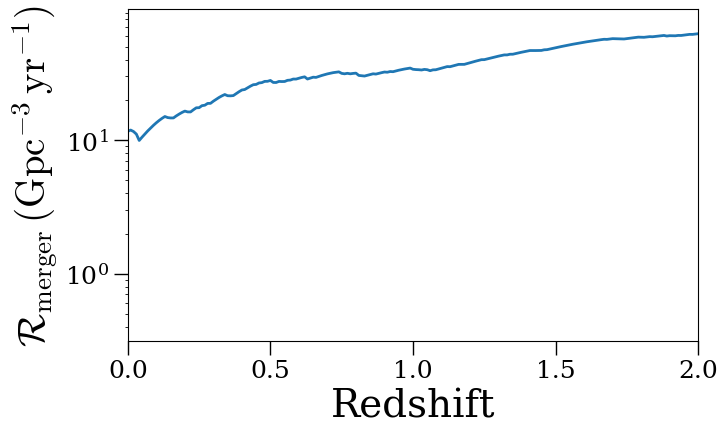

In [5]:
# Quick look: total merger rate vs redshift
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res.redshifts, np.sum(res.merger_rate, axis=0), lw=2)
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\mathcal{R}_\mathrm{merger}\,(\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})$')
ax.set_yscale('log')
ax.set_xlim(0, 2)
fig.tight_layout()

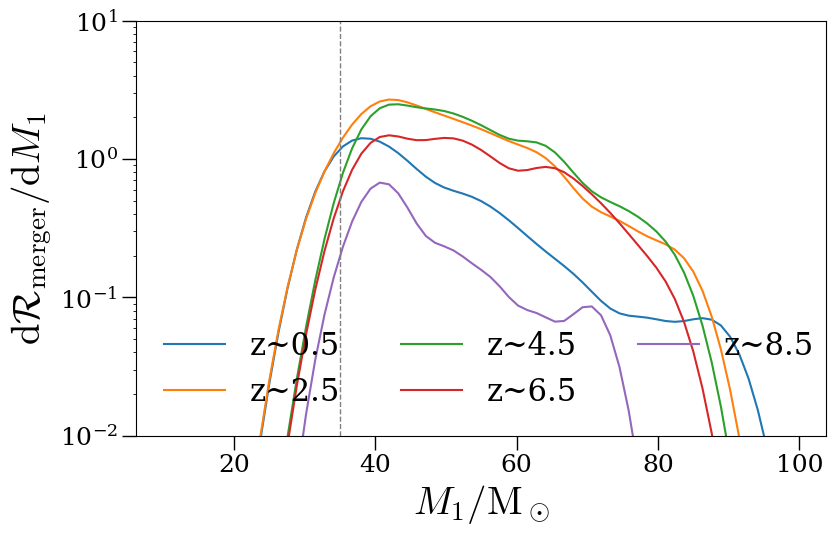

In [6]:
# 2) dR/dM in coarse redshift bins (existing redshift-binned functionality)
# population column indices (for this array format):
# 0=z_div_zsun, 1=m_zams, 2=p_spin_zams, 3=mass, 4=p_orb_f, 5=x_f, 6=x_min_f, 7=log_t_d

fine_edges = np.arange(0.0, config.redshift.max_redshift + config.redshift.redshift_step, config.redshift.redshift_step)
coarse_edges = np.arange(0.0, 11.0, 1.0)
mass_bins = np.linspace(10, 100, 70)

rate_grid_z, z_centers, m_centers = compute_parameter_rate_grid(
    population=pop_arr,
    parameter_col=3,
    intrinsic_rate_density=res.merger_rate,
    fine_redshift_edges=fine_edges,
    coarse_redshift_edges=coarse_edges,
    parameter_bins=mass_bins,
)

fig, ax = plt.subplots(figsize=(9, 6))
for i, zc in enumerate(z_centers):
    if i % 2 != 0:
        continue
    y = rate_grid_z[i]
    if np.any(y > 0):
        ax.plot(m_centers, y, lw=1.5, label=f'z~{zc:.1f}')

ax.set_xlabel(r'$M_1/\mathrm{M}_\odot$')
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')
ax.set_yscale('log')
ax.set_ylim(1e-2, 1e1)
ax.vlines(35, 1e-2, 1e1, ls='--', lw=1, color='gray')
ax.legend(frameon=False, ncol=3)
fig.tight_layout()

Total rate proxy per metallicity bin:
  0.01 < Z/Zsun <= 0.02: 0.0000e+00
  0.02 < Z/Zsun <= 0.0501: 3.5045e+01
  0.0501 < Z/Zsun <= 0.1: 1.3298e+01
  0.1 < Z/Zsun <= 0.2: 5.7788e-06
  0.2 < Z/Zsun <= 0.501: 0.0000e+00
  0.501 < Z/Zsun <= 1: 0.0000e+00


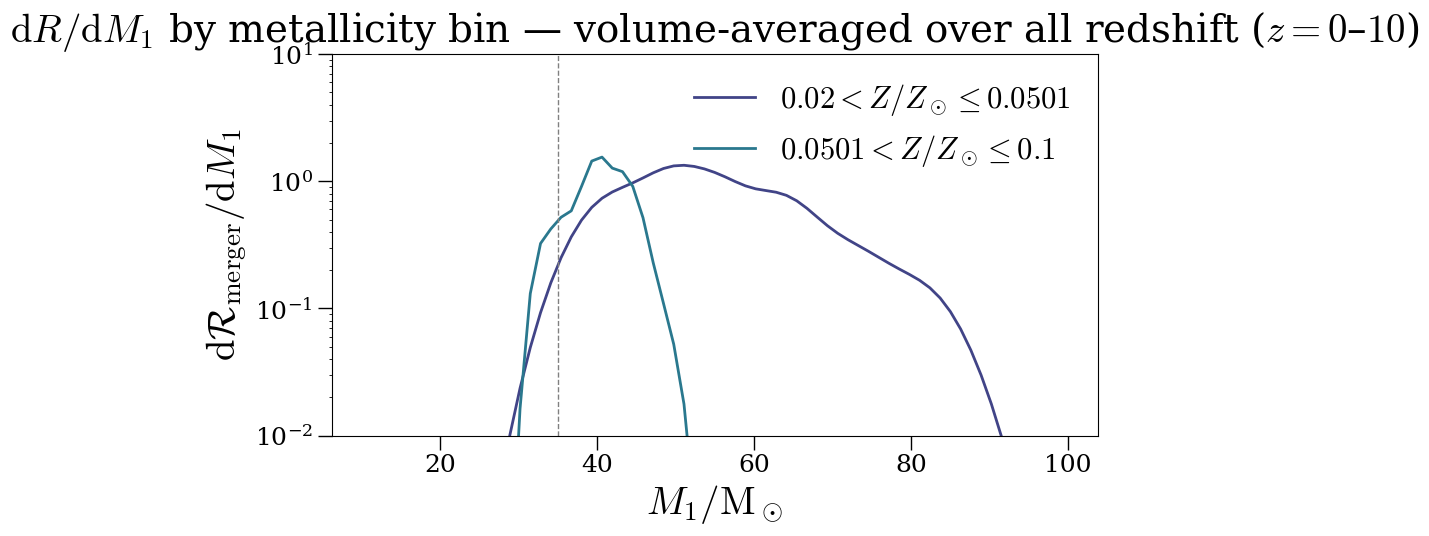

In [7]:
# 3) dR/dM per metallicity bin, marginalized over redshift (new functionality)
# redshift_marginalization='volume_average' → volume-weighted mean over ALL redshifts
# (NOT a single-redshift slice; each system gets weight = sum_z r(z)*dV(z) / V_total)
metallicity_bins = 10.**np.array([-2., -1.7, -1.3, -1., -0.7, -0.3, 0.])

met_result = compute_metallicity_binned_parameter_rate(
    population=pop_arr,
    parameter_col=3,
    metallicity_bins=metallicity_bins,
    parameter_bins=mass_bins,
    intrinsic_rate_density=res.merger_rate,
    metallicity_col=0,
    redshifts=res.redshifts,
    redshift_marginalization='volume_average',
)

ax = plot_metallicity_binned_parameter_rate(
    met_result,
    xlabel=r'$M_1/\mathrm{M}_\odot$',
    ylabel=r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$',
    title=r'$\mathrm{d}R/\mathrm{d}M_1$ by metallicity bin — volume-averaged over all redshift ($z = 0$–$10$)',
)

ax.set_ylim(1e-2, 1e1)
ax.vlines(35, 1e-2, 1e1, ls='--', lw=1, color='gray')

print('Total rate proxy per metallicity bin:')
for i in range(len(met_result.metallicity_centers)):
    lo = met_result.metallicity_edges[i]
    hi = met_result.metallicity_edges[i + 1]
    val = met_result.total_rate_per_metallicity_bin[i]
    print(f'  {lo:.3g} < Z/Zsun <= {hi:.3g}: {val:.4e}')

## Notes
- For spin-based rates, change `parameter_col` from `3` to `5` (`x_f`) or `6` (`x_min_f`).
- For different redshift marginalization behavior in metallicity binning, try `sum`, `trapz`, or `volume_sum`.
- The module returns arrays only; plotting style is fully customizable in the notebook.

## Building from a saved DataFrame: pair-instability on vs off

When the input is a sample DataFrame (HDF5) rather than a pre-saved `.npy` file, use
`build_population_arrays` to convert it.  The key argument is `mass_column`:

| assumption | `mass_column` |
|---|---|
| pair-instability **on** (default) | `'m_post_pi'` |
| pair-instability **off** | `'m_f'` |

Everything else — metallicity column, delay-time column, spin columns — stays the same.
The function returns `(full_array, merger_array)` ready to pass directly to `compute_merger_rates`.

In [8]:
# Load a sample DataFrame saved from the population synthesis grid
sample_path = DATA_DIR / 'ip_pop_minz0.0005_maxz1.0_res1e+08_interpolator_00fiducial_df.h5'
sample_title = sample_path.stem.split('_')[-2]
sample_df = pd.read_hdf(DATA_DIR / 'ip_pop_minz0.0005_maxz1.0_res1e+08_interpolator_00fiducial_df.h5', key='df')
sample_df = sample_df[sample_df.fate_type != 'missing'].reset_index(drop=True)

print(f'DataFrame shape : {sample_df.shape}')
print(f'Columns         : {list(sample_df.columns)}')

DataFrame shape : (6894, 12)
Columns         : ['z_div_zsun', 'm_zams', 'p_spin_zams', 'm_f', 'p_orb_f', 'x_f', 'x_min_f', 'm_tams', 'x_tams', 'log_t_d', 'm_post_pi', 'fate_type']


In [9]:
# Build both array pairs from the same DataFrame, only changing the m1 column
pi_full, pi_pop = build_population_arrays(sample_df, mass_column='m_post_pi')  # pair-instability ON
noPI_full, noPI_pop = build_population_arrays(sample_df, mass_column='m_f')    # pair-instability OFF

# The full array is used for the SFR normalisation (column 1 = m_zams, unchanged).
# The merger sub-array (log_t_d < log(t_Hubble)) is what drives rates.
print(f'PI on  — full: {pi_full.shape}  |  mergers only: {pi_pop.shape}')
print(f'PI off — full: {noPI_full.shape}  |  mergers only: {noPI_pop.shape}')
print()
print('Column layout: [z_div_zsun, m_zams, p_spin_zams, m1, p_orb_f, x_f, x_min_f, log_t_d]')
print('                col 0       col 1   col 2         col 3                               col 7')

PI on  — full: (6894, 8)  |  mergers only: (2788, 8)
PI off — full: (6894, 8)  |  mergers only: (2788, 8)

Column layout: [z_div_zsun, m_zams, p_spin_zams, m1, p_orb_f, x_f, x_min_f, log_t_d]
                col 0       col 1   col 2         col 3                               col 7


In [10]:
# Compute merger rates for both assumptions (config is the same as above)
res_pi   = compute_merger_rates(pi_full, pi_pop, config=config)
res_noPI = compute_merger_rates(noPI_full, noPI_pop, config=config)

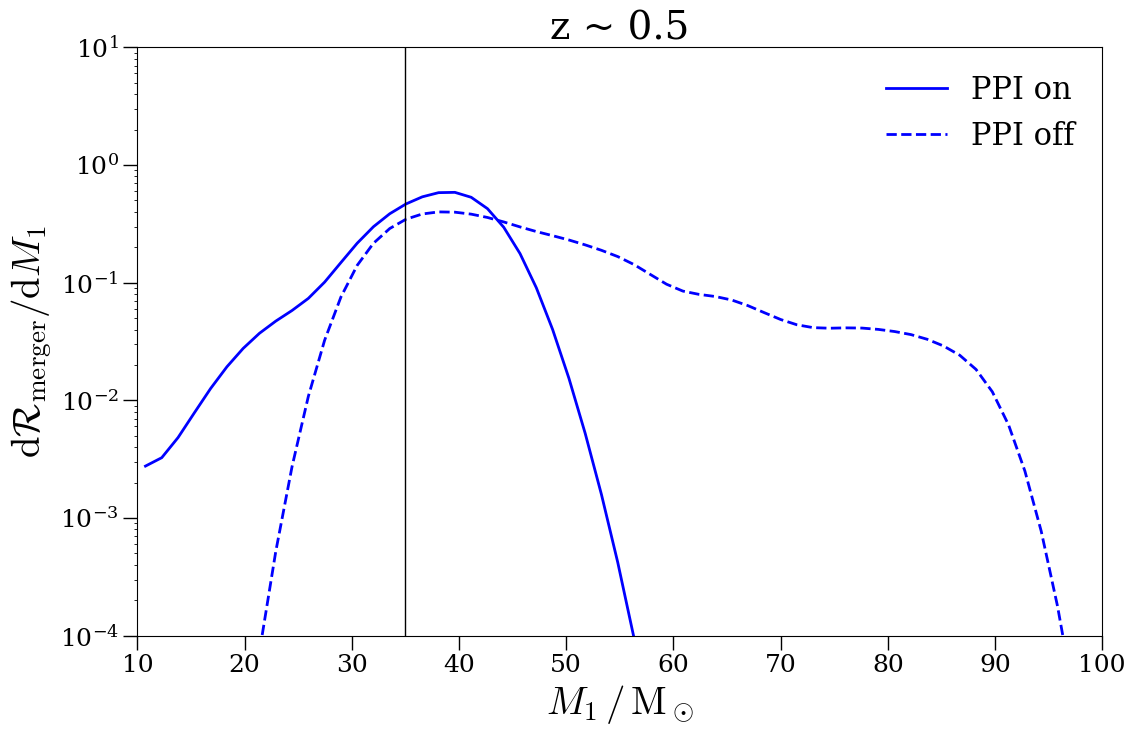

In [24]:
# Compare dR/dM1 at z~0 for pair-instability on vs off
fine_edges   = np.arange(0.0, config.redshift.max_redshift + config.redshift.redshift_step,
                         config.redshift.redshift_step)
coarse_edges = np.arange(0.0, 11.0, 1.0)
mass_bins    = np.linspace(10, 130, 80)
use_kde = True
bw_method = 0.2

rg_pi, z_centers, m_centers = compute_parameter_rate_grid(
    population=pi_pop, parameter_col=3,
    intrinsic_rate_density=res_pi.merger_rate,
    fine_redshift_edges=fine_edges, coarse_redshift_edges=coarse_edges,
    parameter_bins=mass_bins,
    use_kde=use_kde,
    bw_method=bw_method
)
rg_noPI, _, _ = compute_parameter_rate_grid(
    population=noPI_pop, parameter_col=3,
    intrinsic_rate_density=res_noPI.merger_rate,
    fine_redshift_edges=fine_edges, coarse_redshift_edges=coarse_edges,
    parameter_bins=mass_bins,
    use_kde=use_kde,
    bw_method=bw_method

)

plot_i = 0
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(m_centers, rg_pi[plot_i],  'b-', lw=2, label=r'PPI on')
ax.plot(m_centers, rg_noPI[plot_i], 'b--', lw=2, label=r'PPI off')
ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')
ax.set_title(f'z ~ {z_centers[plot_i]:.1f}')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e1)
ax.set_xlim(10, 100)
ax.vlines(35, *ax.get_ylim(), ls='-', lw=1, color='black')  # PI mass-gap edge
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()

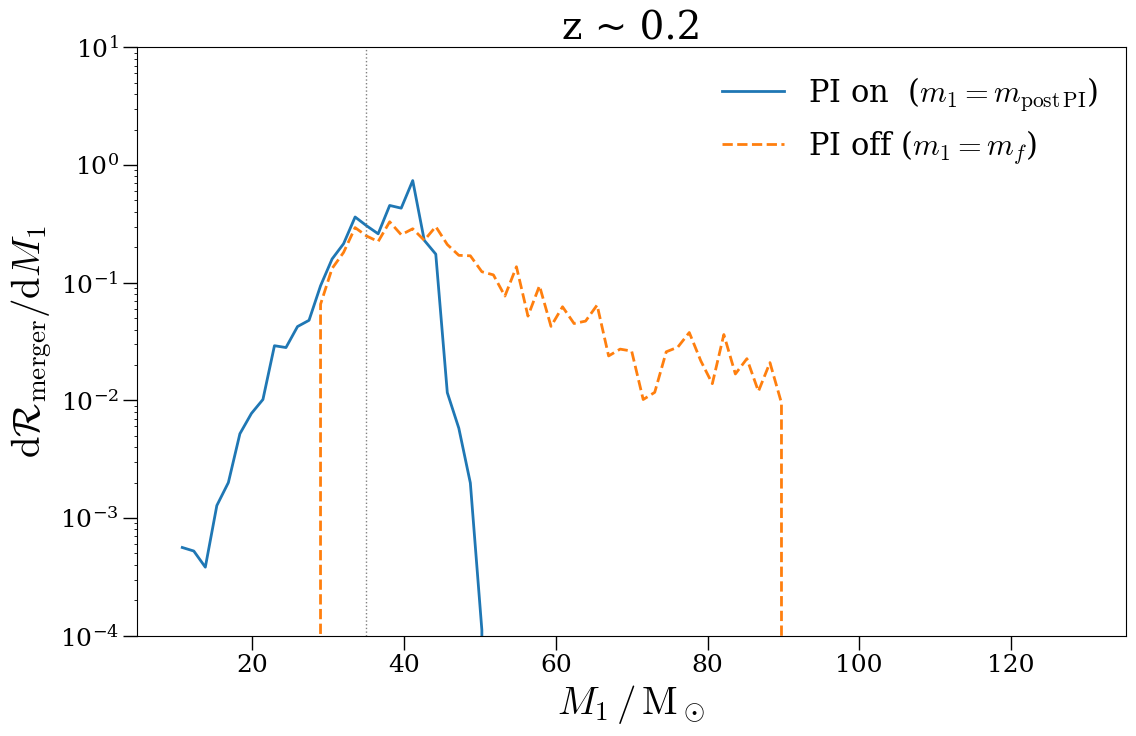

In [12]:
# Compare dR/dM1 at z~0 for pair-instability on vs off
fine_edges   = np.arange(0.0, config.redshift.max_redshift + config.redshift.redshift_step,
                         config.redshift.redshift_step)
coarse_edges = np.arange(0.0, 11.0, 0.5)
mass_bins    = np.linspace(10, 130, 80)
use_kde = False
bw_method = 0.3

rg_pi, z_centers, m_centers = compute_parameter_rate_grid(
    population=pi_pop, parameter_col=3,
    intrinsic_rate_density=res_pi.merger_rate,
    fine_redshift_edges=fine_edges, coarse_redshift_edges=coarse_edges,
    parameter_bins=mass_bins,
    use_kde=use_kde,
    bw_method=bw_method
)
rg_noPI, _, _ = compute_parameter_rate_grid(
    population=noPI_pop, parameter_col=3,
    intrinsic_rate_density=res_noPI.merger_rate,
    fine_redshift_edges=fine_edges, coarse_redshift_edges=coarse_edges,
    parameter_bins=mass_bins,
    use_kde=use_kde,
    bw_method=bw_method

)

# Plot z~0 bin only
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(m_centers, rg_pi[0],   lw=2, label=r'PI on  ($m_1 = m_\mathrm{post\,PI}$)')
ax.plot(m_centers, rg_noPI[0], lw=2, ls='--', label=r'PI off ($m_1 = m_f$)')
ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')
ax.set_title(f'z ~ {z_centers[0]:.1f}')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e1)
ax.vlines(35, *ax.get_ylim(), ls=':', lw=1, color='gray')  # PI mass-gap edge
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()

In [13]:
# Collapse the fine redshift grid to coarse bins so we can isolate a single z-bin.
# crude_pi / crude_noPI shape: (n_systems, n_coarse_bins)
crude_pi   = compute_crude_rate_density(res_pi.merger_rate,   fine_edges, coarse_edges)
crude_noPI = compute_crude_rate_density(res_noPI.merger_rate, fine_edges, coarse_edges)

# First coarse bin is z ∈ [0, 1) → centre z ~ 0.5
z_idx = 0
z_lo, z_hi = coarse_edges[z_idx], coarse_edges[z_idx + 1]
print(f'z bin: [{z_lo}, {z_hi})  →  centre z ~ {z_centers[z_idx]:.1f}')

# Pass the single-bin slice (shape n_systems × 1) and use method='sum'
# so per-system weight = crude rate in that bin only
met_pi_z05 = compute_metallicity_binned_parameter_rate(
    population=pi_pop,
    parameter_col=3,
    metallicity_bins=metallicity_bins,
    parameter_bins=mass_bins,
    intrinsic_rate_density=crude_pi[:, z_idx:z_idx + 1],
    metallicity_col=0,
    redshift_marginalization='sum',
    use_kde=use_kde,
    bw_method=bw_method,
)
met_noPI_z05 = compute_metallicity_binned_parameter_rate(
    population=noPI_pop,
    parameter_col=3,
    metallicity_bins=metallicity_bins,
    parameter_bins=mass_bins,
    intrinsic_rate_density=crude_noPI[:, z_idx:z_idx + 1],
    metallicity_col=0,
    redshift_marginalization='sum',
    use_kde=use_kde,
    bw_method=bw_method,
)

z bin: [0.0, 0.5)  →  centre z ~ 0.2


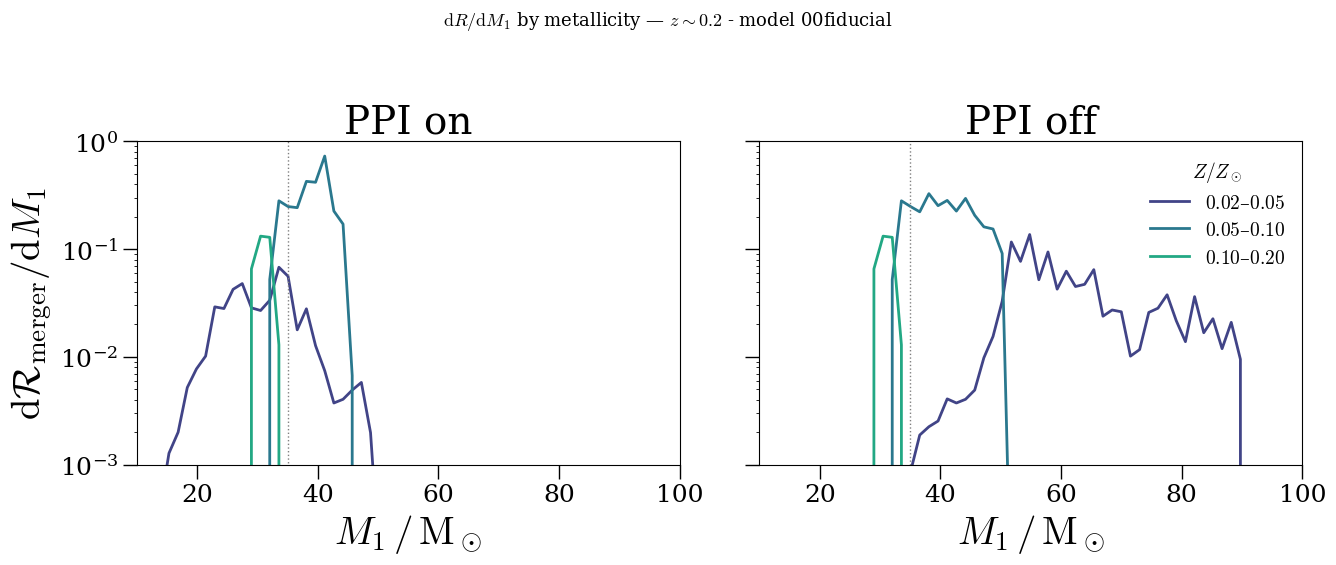

In [14]:
cmap_obj = plt.get_cmap('viridis')
n_met = len(metallicity_bins) - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i_met in range(n_met):
    c = cmap_obj(i_met / max(1, n_met - 1))
    z_lo_m = metallicity_bins[i_met]
    z_hi_m = metallicity_bins[i_met + 1]
    label = f'${z_lo_m:.2f}$–${z_hi_m:.2f}$'

    y_pi   = met_pi_z05.rate_grid[i_met]
    y_noPI = met_noPI_z05.rate_grid[i_met]

    if np.any(y_pi > 0):
        axes[0].plot(met_pi_z05.parameter_centers, y_pi, color=c, lw=2, label=label)
    if np.any(y_noPI > 0):
        axes[1].plot(met_noPI_z05.parameter_centers, y_noPI, color=c, lw=2, label=label)

for ax, title in zip(axes, [
    r'PPI on',
    r'PPI off',
]):
    ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
    ax.set_yscale('log')
    ax.vlines(35, *ax.get_ylim(), ls=':', lw=1, color='gray')
    ax.set_title(title)
    ax.set_ylim(1e-3, 1e0)
    ax.set_xlim(10, 100)

axes[0].set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')
axes[1].legend(
    frameon=False, fontsize=14, loc='upper right',
    title=r'$Z/Z_\odot$', title_fontsize=14,
)
fig.suptitle(
    rf'$\mathrm{{d}}R/\mathrm{{d}}M_1$ by metallicity — $z \sim {z_centers[z_idx]:.1f}$ - model {sample_title}',
    fontsize=13,
)
fig.tight_layout()

In [15]:
def plot_multi_model_fixed_z_ppi_comparison(
    all_datasets_dict,
    fixed_z=0.5,
    mass_bins=np.linspace(10, 130, 80),
    use_kde=False,
    bw_method=0.3,
    config=None,
    figsize=(14, 10),
    cmap='viridis',
):
    """Plot dR/dM1 at a fixed coarse-z bin for multiple models.

    Parameters
    ----------
    all_datasets_dict : dict
        Mapping {id: {'title': model_title, 'path': df_path}}, sorted by ID.
        DataFrames must contain columns used by build_population_arrays,
        including m_post_pi and m_f.
    fixed_z : float
        Target redshift (mapped to coarse bin [floor(z), floor(z)+1)).
    mass_bins : np.ndarray
        Mass bin edges for dR/dM1.
    use_kde : bool
        Use KDE smoothing in compute_parameter_rate_grid.
    bw_method : float
        KDE bandwidth passed through when use_kde=True.
    config : RateComputationConfig or None
        Uses default RateComputationConfig() when None.
    cmap : str
        Colormap name to use for ID-based coloring.
    """
    if config is None:
        config = RateComputationConfig()

    fine_edges = np.arange(
        0.0,
        config.redshift.max_redshift + config.redshift.redshift_step,
        config.redshift.redshift_step,
    )
    coarse_edges = np.arange(0.0, 11.0, 1.0)
    z_centers = 0.5 * (coarse_edges[:-1] + coarse_edges[1:])

    # Map fixed_z to its coarse [z, z+1) bin; clip to available bins.
    z_idx = int(np.floor(fixed_z))
    z_idx = int(np.clip(z_idx, 0, len(z_centers) - 1))

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    cmap_obj = plt.get_cmap(cmap)
    sorted_ids = sorted(all_datasets_dict.keys())
    n_models = len(sorted_ids)
    
    # Build legend handles and labels
    legend_handles = []
    legend_labels = []

    # Iterate through datasets in sorted ID order
    for i, dataset_id in enumerate(sorted_ids):
        # Map ID to color
        color = cmap_obj(i / max(1, n_models - 1))
        
        model_title = all_datasets_dict[dataset_id]['title']
        df_path = all_datasets_dict[dataset_id]['path']

        sample_df = pd.read_hdf(df_path, key='df')
        if 'fate_type' in sample_df.columns:
            sample_df = sample_df[sample_df.fate_type != 'missing'].reset_index(drop=True)

        pi_full, pi_pop = build_population_arrays(sample_df, mass_column='m_post_pi')
        noPI_full, noPI_pop = build_population_arrays(sample_df, mass_column='m_f')

        res_pi = compute_merger_rates(pi_full, pi_pop, config=config)
        res_noPI = compute_merger_rates(noPI_full, noPI_pop, config=config)

        rg_pi, _, m_centers = compute_parameter_rate_grid(
            population=pi_pop,
            parameter_col=3,
            intrinsic_rate_density=res_pi.merger_rate,
            fine_redshift_edges=fine_edges,
            coarse_redshift_edges=coarse_edges,
            parameter_bins=mass_bins,
            use_kde=use_kde,
            bw_method=bw_method,
        )
        rg_noPI, _, _ = compute_parameter_rate_grid(
            population=noPI_pop,
            parameter_col=3,
            intrinsic_rate_density=res_noPI.merger_rate,
            fine_redshift_edges=fine_edges,
            coarse_redshift_edges=coarse_edges,
            parameter_bins=mass_bins,
            use_kde=use_kde,
            bw_method=bw_method,
        )

        axes[0].plot(m_centers, rg_pi[z_idx], lw=2, color=color)
        axes[1].plot(m_centers, rg_noPI[z_idx], lw=2, color=color)
        
        # Store for legend
        legend_handles.append(plt.Line2D([0], [0], lw=2, color=color))
        legend_labels.append(f'ID {dataset_id}: {model_title}')

    axes[0].set_title('PPI on')
    axes[1].set_title('PPI off')

    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlim(mass_bins[0], mass_bins[-1])
        ax.vlines(35, *ax.get_ylim(), ls=':', lw=1, color='gray')

    axes[1].set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
    axes[0].set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')
    axes[1].set_ylabel(r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}M_1$')

    # Single legend outside panels
    fig.legend(
        legend_handles, legend_labels,
        loc='center left', bbox_to_anchor=(1.01, 0.5),
        frameon=False, fontsize=10, ncol=1
    )

    fig.suptitle(
        rf'Multi-model dR/dM1 comparison at $z \sim {z_centers[z_idx]:.1f}$ '
        rf'({"KDE" if use_kde else "hist"}; bw={bw_method})'
    )
    fig.tight_layout()
    return fig, axes


# Example usage:
# fig, axes = plot_multi_model_fixed_z_ppi_comparison(
#     all_datasets_dict,
#     fixed_z=0.5,
#     use_kde=True,
#     bw_method=0.3,
#     cmap='viridis',
# )

In [19]:
all_datasets_dict = {}
for path in DATA_DIR.glob('ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_*_df.h5'):
    id = int(path.stem.split('_')[8])
    title = '_'.join(path.stem.split('_')[5:-1])
    all_datasets_dict[id] = {
        'title': title,
        'path': path,
    }

In [20]:
all_datasets_dict

{11: {'title': 'corrected_mi_z_11_efficient_mix',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_11_efficient_mix_df.h5')},
 3: {'title': 'corrected_mi_z_03_strong_winds',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_03_strong_winds_df.h5')},
 9: {'title': 'corrected_mi_z_09_early_wind_transition',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_09_early_wind_transition_df.h5')},
 6: {'title': 'corrected_mi_z_06_flat_z_winds',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_06_flat_z_winds_df.h5')},
 5: {'title': 'corrected_mi_z_05_steep_m_winds',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_05_steep_m_winds_df.h5')},
 7: {'title': 'corrected_mi_z_07_steep_z_winds',
  'path': PosixPath('../data/ip_pop_minz0.0005_maxz1.0_res1e+07_corrected_mi_z_07_steep_z_winds_df.h5')},
 4: {'title': 'corrected_mi_z_04_flat_m_winds',
  'path':

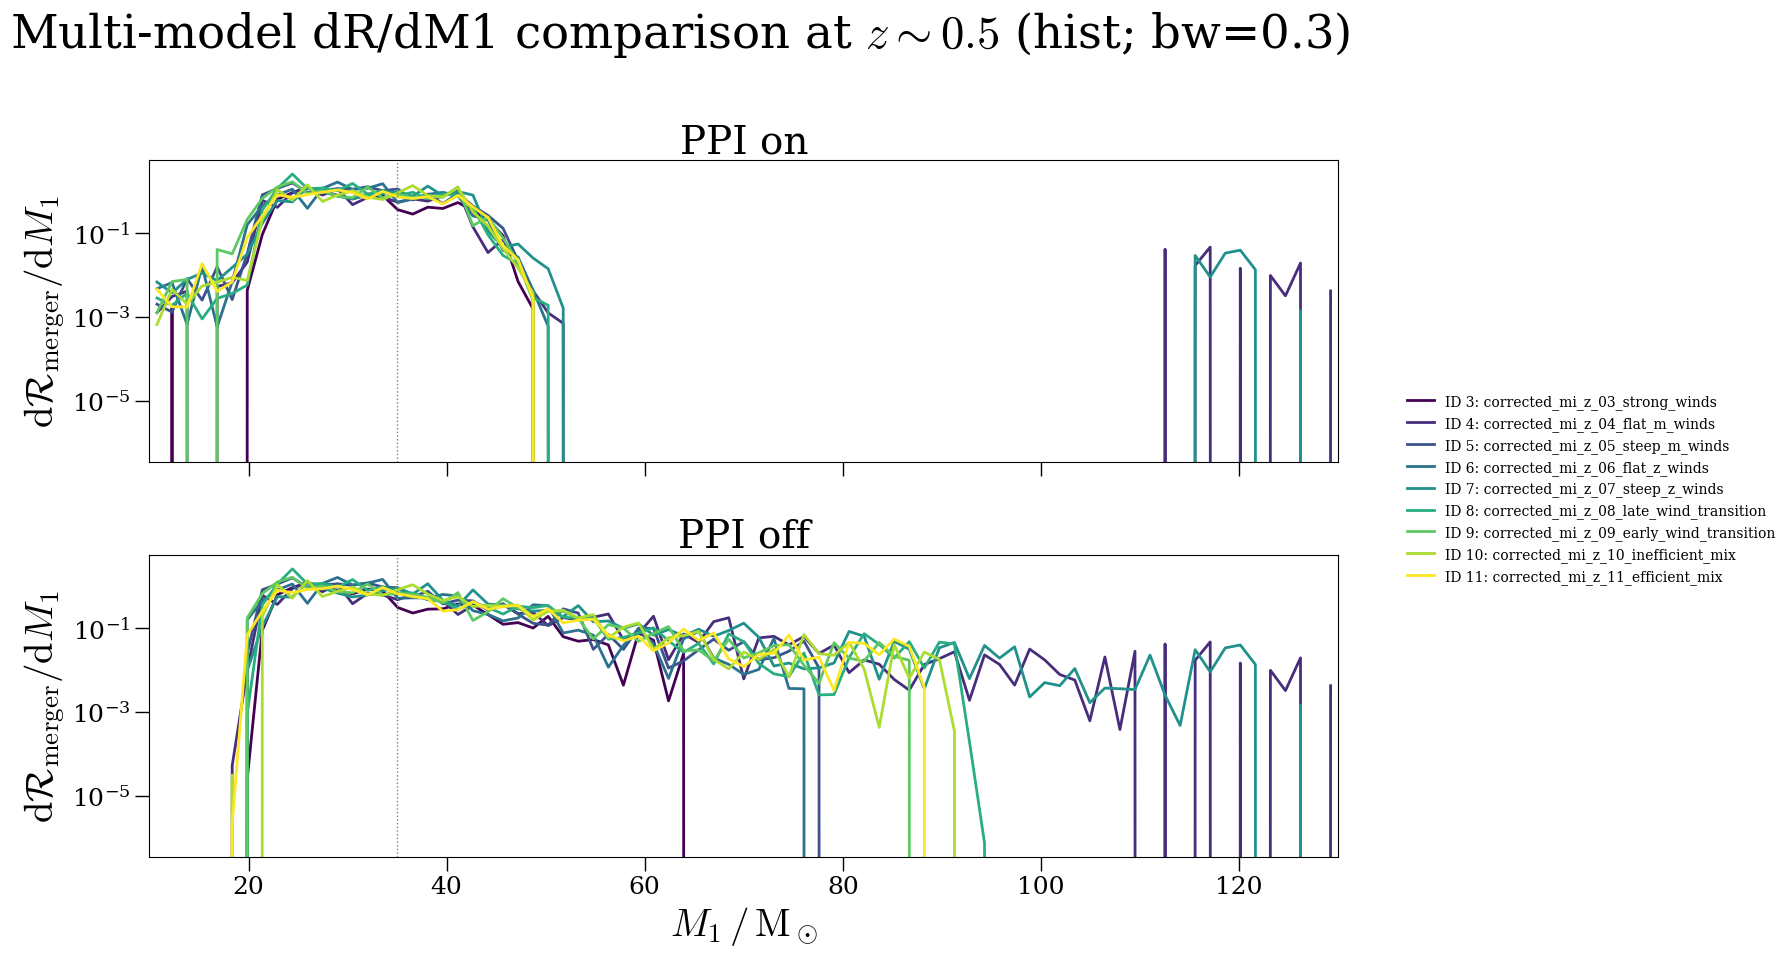

In [21]:
fig, axes = plot_multi_model_fixed_z_ppi_comparison(
    all_datasets_dict,
    fixed_z=0.5,
    use_kde=False,
    bw_method=0.3,
)

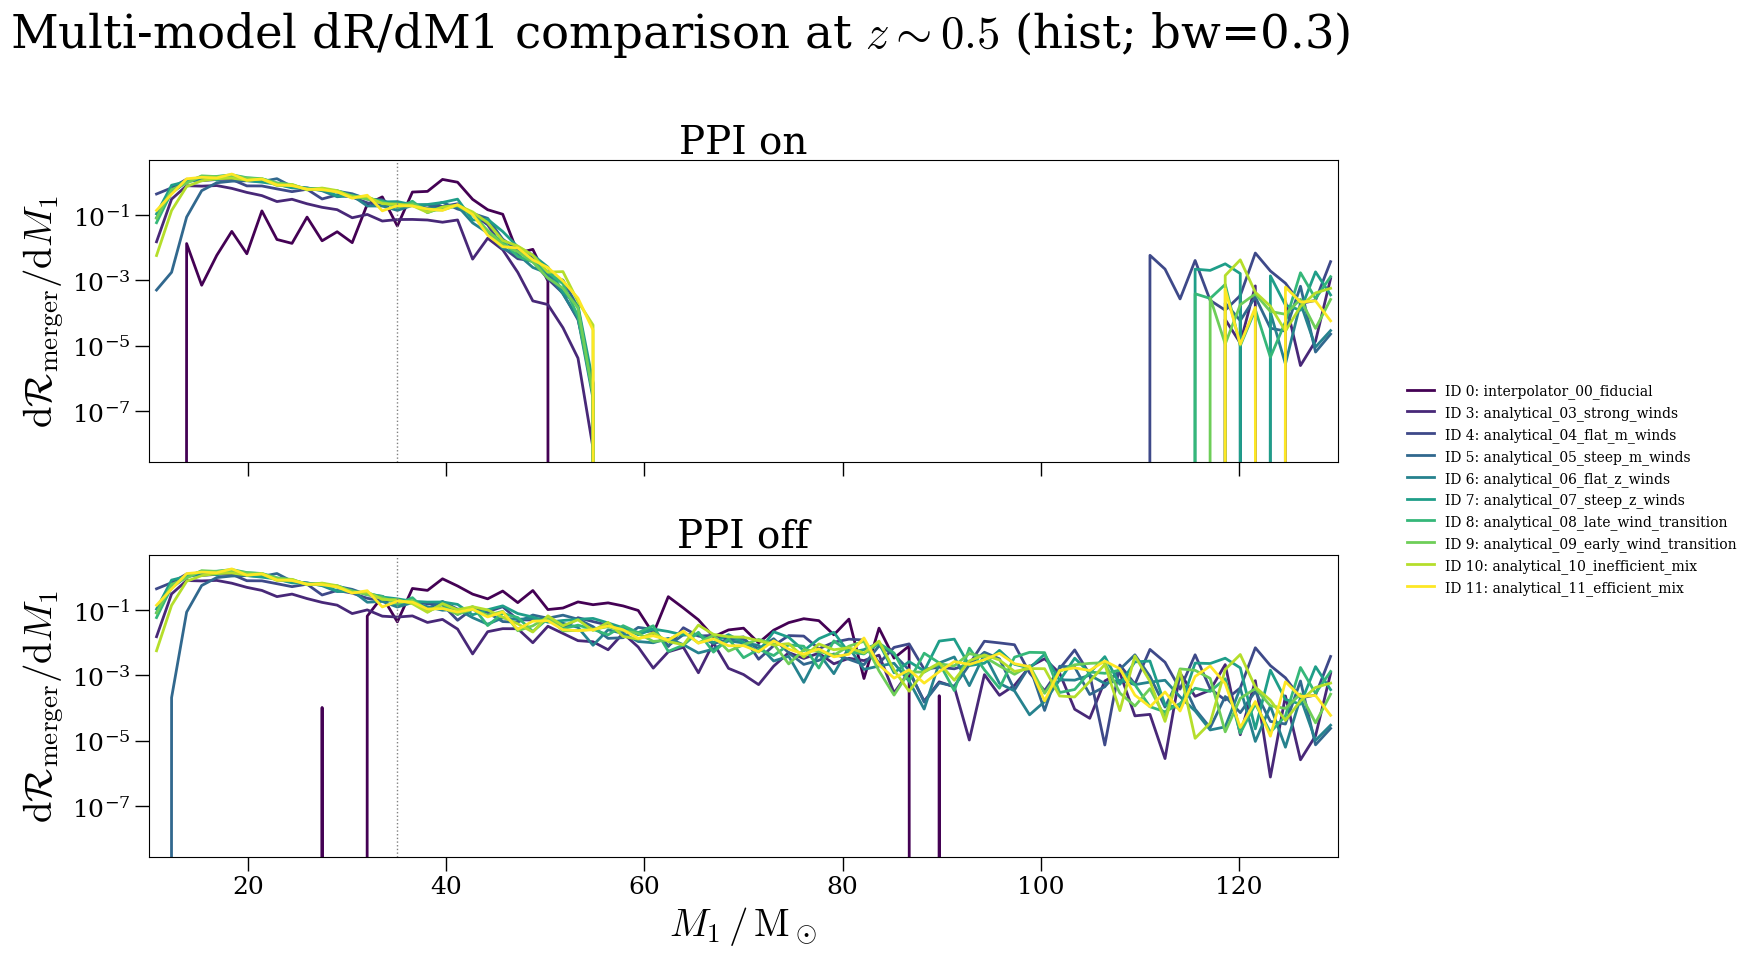

In [ ]:
fig, axes = plot_multi_model_fixed_z_ppi_comparison(
    all_datasets_dict,
    fixed_z=0.5,
    use_kde=False,
    bw_method=0.3,
)